# Assignment

Use the "from the expert" (FTE) jupyter notebook as a starter for this assignment, and ask your instructor questions if you need help.

Use our saved churn data from week 2 with machine learning to predict if customers will churn or not, similar to what we did in the FTE:

- break up data into features and targets
- split data into train and test sets
- use at least one ML model to fit to the training data
- evaluate performance on the train and test sets: at least evaluate accuracy and compare it with the "no information rate"
- plot a confusion matrix
- write something describing how the ML algorithm could be used in a business setting
- Write a short summary of what you did with the overall process - describe any important EDA findings, data cleaning and preparation, modeling, and evaluation in your summary.

*Optional*: For an addition challenge, try the following:
- fit more ML models and compare their scores
- optimize the hyperparameters of your models
- examine more metrics such as the classification report and ROC/AUC
- plot the distribution of the probability predictions (from the `predict_proba()` function from our model) for each class (1s and 0s)

### DS process status

Here is our data science process, and where we are (#4):

**1. Business understanding**

Can we use machine learning to predict if a customer will churn before they leave?

**2. Data understanding**

Week 1 - EDA and visualization.

**3. Data preparation**

Last week - cleaning and feature engineering.


**4. Modeling**

This week.
Fit a ML model to the data.


**5. Evaluation**

This week.
Check the performance of our models and evaluate how it fits our goals from step 1.


**6. Deployment**

This week.
Describe how the model might be deployed and used at the business. Will there be an API that customer service reps can use when customers call? Should there be a system where a report gets sent to someone in customer retention or marketing with at-risk customers? We should really think about these things in the first step, although we can consider them here this time.

In [25]:
#Loading our data

import pandas as pd

df = pd.read_csv('churn_cleaned.csv')
df.head()

,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check,yj_tenure,yj_monthly_charges,yj_total_charges,MonthlyCharges_over_Median
0,1,0,29.85,29.85,0,1,0,0,0,0,1,0,-1.649511,-1.159996,-1.810069,-40.50
1,34,1,56.95,1889.50,0,0,1,0,0,0,0,1,0.294467,-0.241345,0.254257,-13.40
2,2,1,53.85,108.15,1,1,0,0,0,0,0,1,-1.500657,-0.344532,-1.386091,-16.50
3,45,0,42.30,1840.75,0,0,1,0,1,0,0,0,0.644481,-0.732875,0.233220,-28.05
4,2,1,70.70,151.65,1,1,0,0,0,0,1,0,-1.500657,0.211884,-1.248808,0.35


In [26]:
'''
Let's normalize any nurmeric data that we have.
We have already normalized monthly charges, tenure, and total charges, so let's
get rid of the regular columns for each variable and only keep their normalized
versions.
'''

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

normal_df = df.copy()


normal_df.drop('tenure', inplace=True, axis=1)
normal_df.drop('MonthlyCharges', inplace=True, axis=1)
normal_df.drop('TotalCharges', inplace=True, axis=1)
normal_df['MonthlyCharges_over_Median'] = scaler.fit_transform(normal_df[['MonthlyCharges_over_Median']])

normal_df.head()

,PhoneService,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check,yj_tenure,yj_monthly_charges,yj_total_charges,MonthlyCharges_over_Median
0,0,0,1,0,0,0,0,1,0,-1.649511,-1.159996,-1.810069,-1.161694
1,1,0,0,1,0,0,0,0,1,0.294467,-0.241345,0.254257,-0.260878
2,1,1,1,0,0,0,0,0,1,-1.500657,-0.344532,-1.386091,-0.363923
3,0,0,0,1,0,1,0,0,0,0.644481,-0.732875,0.233220,-0.747850
4,1,1,1,0,0,0,0,1,0,-1.500657,0.211884,-1.248808,0.196178


In [27]:
'''
Breaking our dataset into train and test sets
'''

from sklearn.model_selection import train_test_split

x = normal_df.drop('Churn', axis=1)
y = normal_df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [28]:
'''
Now let's use an algorithm to fit the training data.
We are going to use logistic regression since our target variable is a binary option.
'''

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train, y_train)
y_predict = lr_model.predict(x_test)

In [29]:
normal_df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [30]:
'''
Now we want to see our score to see how well the model did.
Let's also look at the majority class fraction to see the improvement our model has
'''

mcf = round(normal_df['Churn'].value_counts(normalize=True)[0], 5)
print('No information rate: ', mcf, '\n')
ts = round(lr_model.score(x_train, y_train), 5)
ta = round(lr_model.score(x_test, y_test), 5)
print('Training Score = ', ts)
print('Test accuracy = ', ta, '\n')
print('Difference between training score and test accuracy: ', round(abs(ts - ta), 5))
print('\n Increased accuracy of training score over the no informatin rate: ', round(ts-mcf, 3))

No information rate:  0.73422 

Training Score =  0.7956
Test accuracy =  0.7992 

Difference between training score and test accuracy:  0.0036

 Increased accuracy of training score over the no informatin rate:  0.061


Type 1 error =  16.64 %
Type 2 error =  35.4 %


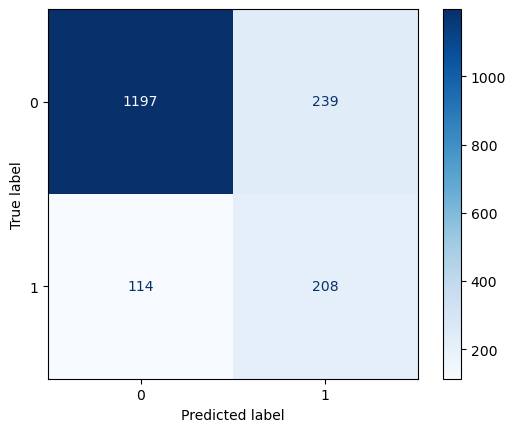

In [31]:
'''
Let's plot a confusion matrix.
The worst error here is type 2 (false negative).  If we predict that a customer won't churn,
but then they do churn, then that is loss money for the company.  For type 1 error, if we 
predict that the customer will churn but then they don't, well then that's actually good
for the company.  Our type 2 error is the highest in this confusion matrix, so that is 
not great.
'''

from sklearn.metrics import ConfusionMatrixDisplay

_ = ConfusionMatrixDisplay.from_predictions(y_predict, y_test, cmap='Blues')
print('Type 1 error = ', round((239/(239+1197))*100, 2), '%')
print('Type 2 error = ', round((114/(114+208))*100, 2), '%')

Index(['PhoneService', 'Month-to-month', 'One year', 'Two year',
       'Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check', 'yj_tenure', 'yj_monthly_charges',
       'yj_total_charges', 'MonthlyCharges_over_Median'],
      dtype='object')
[[-0.89281769  0.78970125 -0.11737812 -1.28032017 -0.13771486 -0.3435564
   0.24744085 -0.37416663  0.28425483  0.62906466 -1.37068878  0.78729748]]


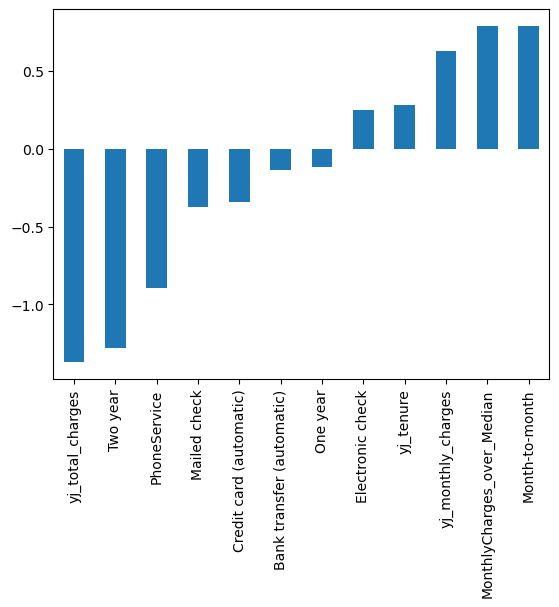

In [32]:
'''
Let's take a look at how much influence each feature has on churn
'''

coef_df = pd.DataFrame(data=lr_model.coef_, columns=normal_df.drop('Churn', axis=1).columns)
_ = coef_df.T.sort_values(by=0).plot.bar(legend=False)
print(normal_df.drop('Churn', axis=1).columns)
print(lr_model.coef_)

In [33]:
'''
Let's fit some more machine learning models to see if we can optimize our results.
Let's use a random forest classifier.
'''

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=0)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

rf_ts = round(rf_model.score(x_train, y_train), 5)
rf_ta = round(rf_model.score(x_test, y_test), 5)
print('Training score: ', rf_ts)
print('Test accuracy: ', rf_ta)
print('\n Improvement over no information: ', round(rf_ts - mcf, 5))

Training score:  0.80375
Test accuracy:  0.79863

 Improvement over no information:  0.06953


Type 1 error:  7.323 %
Type 2 error:  57.718 %


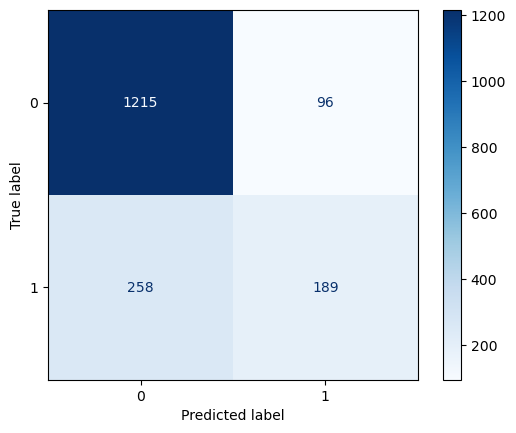

In [34]:
'''
Plotting our confusion matrix.
We see that our type 1 error went down while our type two error went
up.  This is actually much worse, as we wanted to minimize type 2 error.
'''
_ = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')

type_1 = (96/(96+1215))*100
type_2 = (258/(258+189))*100

print('Type 1 error: ', round(type_1, 3), '%')
print('Type 2 error: ', round(type_2, 3), '%')

This random forest classification model seems to have little improvement on the training accuracy while only increasing our type 2 error (the error we want to avoid).  Therefore, we would problably stick with our original model.

In [35]:
'''
Let's try optimizing our hyperparameters
We see that our training accuracy is the closest to the test accuracy
out of all the methods we have tried so far!
'''

from skopt import BayesSearchCV

opt = BayesSearchCV(
    RandomForestClassifier(),
    {
        'max_depth': (3, 20),
        'n_estimators': (50, 500),
        'max_features': (3, 14),
        'min_samples_split': (2, 5)
    },
    n_iter=32,
    cv=3,
    random_state = 0
)

opt.fit(x_train, y_train)
y_pred_opt = opt.predict(x_test)
ts = round(opt.best_score_, 5)
ta = round(opt.score(x_test, y_test), 5)

print('Training score: ', ts)
print('Test accuracy: ', ta)

Training score:  0.79503
Test accuracy:  0.7992


Type 1 error:  9.0 %
Type 2 error:  52.57 %


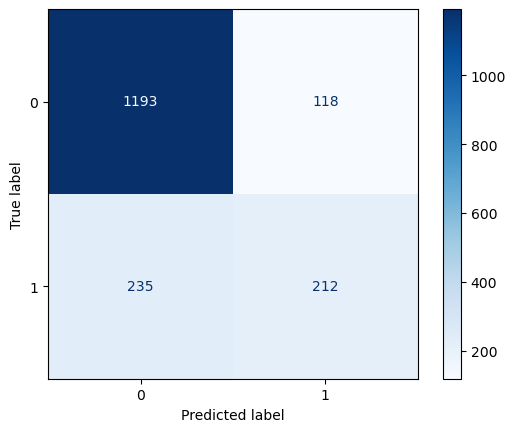

In [45]:
#Confusion matrix for our Bayes Search Model

_ = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, cmap='Blues')

type_1_opt = round((118/(118+1193))*100, 2)
type_2_opt = round((235/(235+212))*100, 2)
print('Type 1 error: ', type_1_opt, '%')
print('Type 2 error: ', type_2_opt, '%')

In [37]:
'''
Let's look at the classification report for our hyperparamterized model
as well as our other two models.
Out of all the scores, we would want a high recall.  It seems that all
of our scores are relatively the same. 
'''

from sklearn.metrics import classification_report

print('Bayes Search Model')
print(classification_report(y_test, opt.predict(x_test)))

Bayes Search Model
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1311
           1       0.64      0.47      0.55       447

    accuracy                           0.80      1758
   macro avg       0.74      0.69      0.71      1758
weighted avg       0.79      0.80      0.79      1758



In [38]:
print('Random Forest Model')
print(classification_report(y_test, rf_model.predict(x_test)))

Random Forest Model
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1311
           1       0.66      0.42      0.52       447

    accuracy                           0.80      1758
   macro avg       0.74      0.67      0.69      1758
weighted avg       0.78      0.80      0.78      1758



In [39]:
print('Logistic Regression Model')
print(classification_report(y_test, lr_model.predict(x_test)))

Logistic Regression Model
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1311
           1       0.65      0.47      0.54       447

    accuracy                           0.80      1758
   macro avg       0.74      0.69      0.71      1758
weighted avg       0.79      0.80      0.79      1758



0.8368246996247549


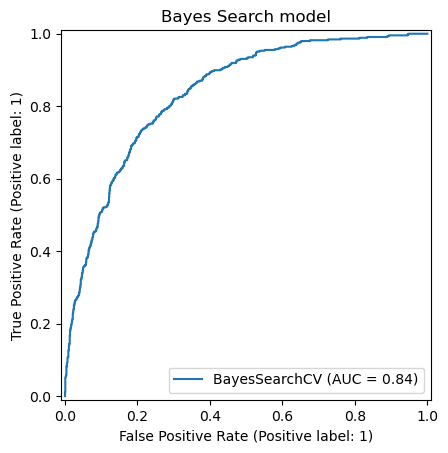

In [53]:
'''
Let's plot a reciever operating characteristic (ROC) and AUC score.
'''

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

roc = roc = RocCurveDisplay.from_estimator(opt, x_test, y_test)
print(roc.roc_auc)
_ = plt.title('Bayes Search model')

0.8356319014636093


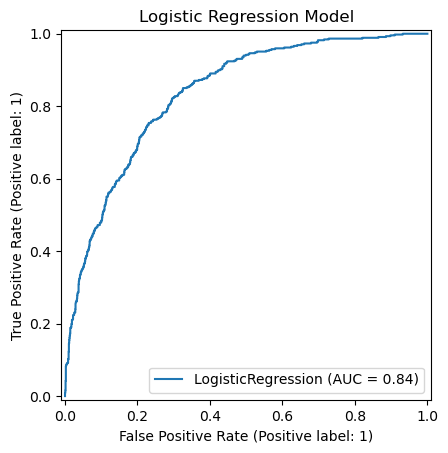

In [52]:
'''
Let's look at the roc curve for our other two models
'''

roc = RocCurveDisplay.from_estimator(lr_model, x_test, y_test)
print(roc.roc_auc)
_ = plt.title('Logistic Regression Model')

0.8359672159681376


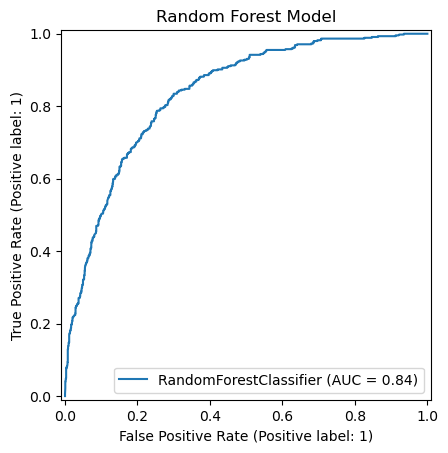

In [51]:
roc = RocCurveDisplay.from_estimator(rf_model, x_test, y_test)
print(roc.roc_auc)
_ = plt.title('Random Forest Model')

It seems that all of the models are very similar in auc scores and classification scores.  However, the logistic regression stills holds the smalles type 2 error, which is the error we want to minimize.

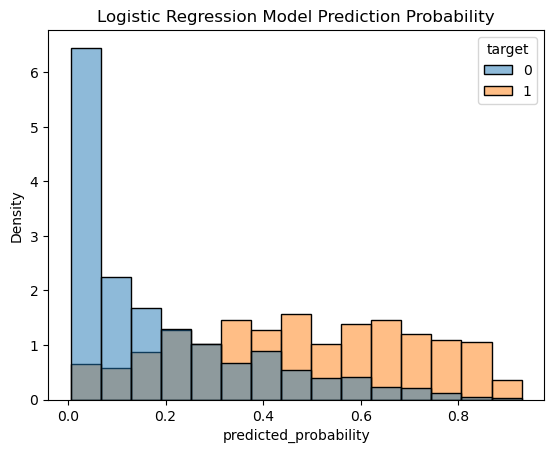

In [50]:
'''
Lastly, let's look at the prediction probability for the logistice regression
model.
We can see that our model is decently confident when it predicts that
someone is going to churn.
'''

import seaborn as sns

probab = lr_model.predict_proba(x_test)[:, 1]
prob_df = pd.DataFrame(data={'predicted_probability': probab, 'target': y_test})
sns.histplot(data=prob_df, x='predicted_probability', hue='target', stat='density', common_norm=False)
_ = plt.title('Logistic Regression Model Prediction Probability')

# 6. Deployment

Write a small description of how we might use this ML algorithm in a business setting.

If we were to bring these findings to a buisness, we would want to find a way to feed new customer information and update current customer information into our model on a consistent basis so that is could be updated going forward.  We would want to use the variables most correlated to churn to find solutions to minimize these problems.  Maybe we could find a 'breakpoint' for monthly charges that minimizes the amount of customers who would churn while still making money.

# Summary

Write your summary here.

We have finished running our data through machine learning algorithms to get model to predict whether a customer will churn or not.  We started by normalizing all of our numeric data and then running a logistic regression on it.  After training the data, we found that it is about 80% accurate, which is the same as the test data would suggest.  This model accuracy is also much better than our model class fraction, which is about 73%.  We then looked at the two types of error that we could get and found that the chance to type 1 error is 16.64 percent while the chance of type 2 error is 35.4 percent.  Lastly, we found that the total charges has the most influence on whether or not someone decides to churn.  Some other important features include the type of contract and the monthly charges.

Next we looked at some other models for our data.  We looked at a random tree classification and a Bayes Search Model.  Both models showed similar results to our logistic regression, with similar training scores of about 80% and a similar classification report.  We then looked at the ROC curve for each model, and again they all returned similar results.  We decided to use our original logistic regression model since it had the lowest type 2 error.  We then looked at the prediction probability scores for the model and saw that our model is decently confident in its predictions.